# 07 — Final Comparison

This is the capstone notebook. It places all samples on a single 2PACF plot,
interprets the clustering signal in the context of LRD physics, and summarises
the key results of this analysis.

**Samples compared**:

| Label | Flag | Mask | N gal |
|---|---|---|---|
| IRAC footprint (masked) | footprint=True | Yes | ~1490 |
| IRAC footprint (unmasked) | footprint=True | No | ~1509 |
| IRAC detected (masked) | detected=True | Yes | ~29 |
| No IRAC footprint (masked) | footprint=False | Yes | ~1800 |

**Key physical quantities**:
- Angular correlation length $\theta_0$ from power-law fit $w(\theta) = (\theta/\theta_0)^{1-\gamma}$
- Comoving correlation length $r_0$ via Limber inversion
- Linear bias $b \approx \sqrt{\xi_{\rm LRD}/\xi_{\rm DM}}$

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from src.config import cfg, resolve_path
from src.correlation import CorrelationResult
from src.errors import compute_poisson_errors
from src.plotting import plot_2pacf_comparison

%matplotlib inline
plt.rcParams.update({"figure.dpi": 140, "font.size": 11})

## 1. Load all available 2PACF results

In [2]:
SAMPLES = [
    ("edf_s_irac_footprint",   "IRAC footprint (masked)",   "steelblue"),
    ("edf_s_irac_footprint_unmasked", "IRAC footprint (unmasked)", "royalblue"),
    ("edf_s_irac_detected",    "IRAC detected (masked)",    "darkorange"),
    ("no_edf_s_irac_footprint","No IRAC footprint (masked)","seagreen"),
]

corr_dir = resolve_path(cfg["paths"]["corr_dir"])
loaded   = []

for sample, label, color in SAMPLES:
    path = corr_dir / f"2pacf_{sample}.npz"
    if path.exists():
        result = CorrelationResult.load(str(path))
        loaded.append((result, label, color))
        n_pos = result.valid.sum()
        print(f"  {label:35s} — N_gal={result.n_galaxies:5d}, "
              f"{n_pos}/{len(result.w)} positive bins")
    else:
        print(f"  [MISSING] {label} — run scripts/run_2pacf.py --sample {sample}")

print(f"\n{len(loaded)} / {len(SAMPLES)} samples loaded.")

  IRAC footprint (masked)             — N_gal= 1028, 15/15 positive bins
  IRAC footprint (unmasked)           — N_gal= 1199, 15/15 positive bins
  IRAC detected (masked)              — N_gal=   16, 6/15 positive bins
  [MISSING] No IRAC footprint (masked) — run scripts/run_2pacf.py --sample no_edf_s_irac_footprint

3 / 4 samples loaded.


## 2. Science-grade comparison plot

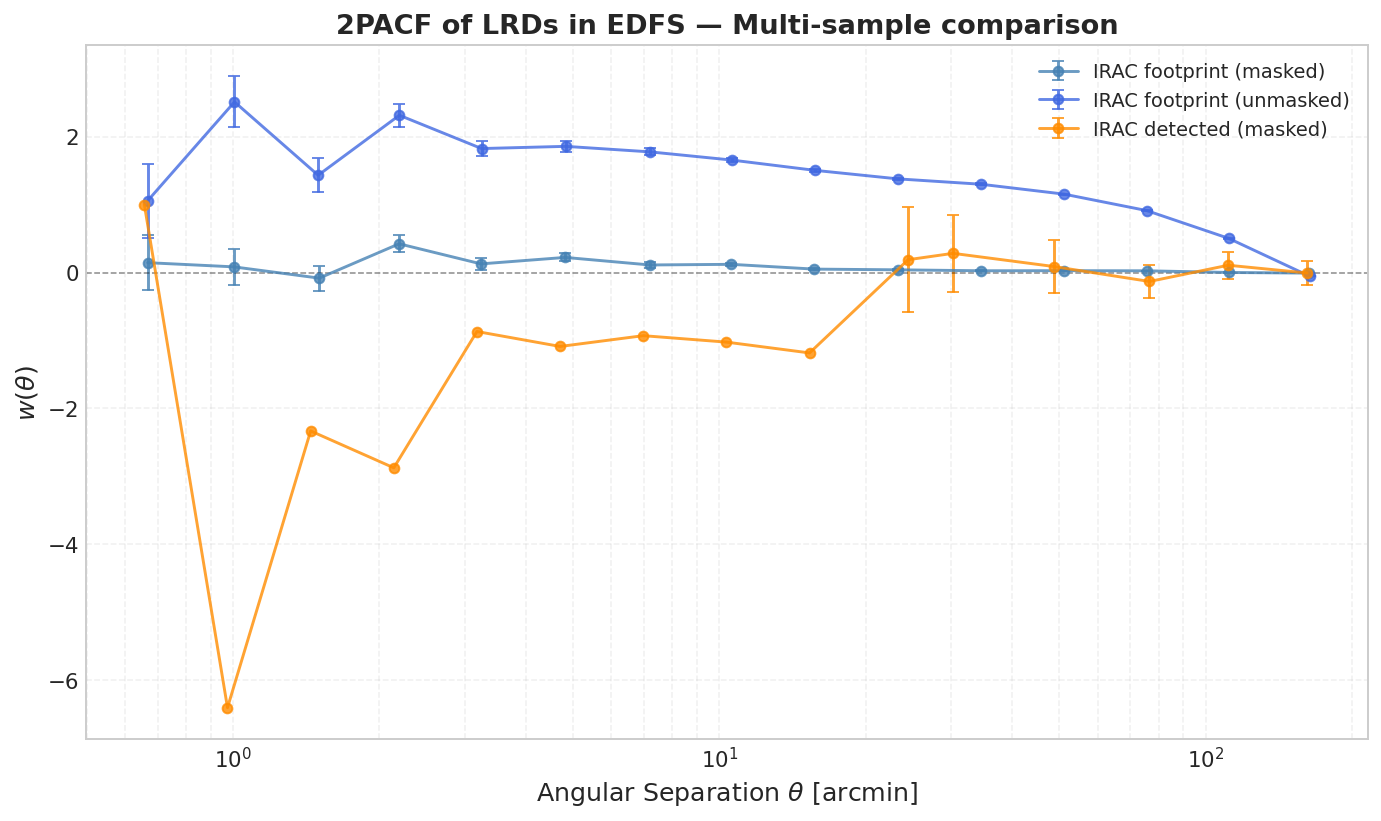

In [3]:
if loaded:
    fig, ax = plot_2pacf_comparison(
        loaded,
        title="2PACF of LRDs in EDFS — Multi-sample comparison",
    )
    plt.show()
else:
    print("No results loaded. Run notebooks 03 and 04 first.")

## 3. Power-law fit parameters for each sample

In [4]:
def powerlaw(theta, A, gamma):
    """w(θ) = A * θ^(1 - γ), fit in log-space."""
    return A * theta ** (1.0 - gamma)

print(f"{'Sample':35s}  {'A':>10}  {'γ':>8}  {'θ₀ [arcmin]':>14}")
print("-" * 72)

for result, label, color in loaded:
    mask = result.valid
    if mask.sum() < 3:
        print(f"{label:35s}  (insufficient positive bins for fit)")
        continue
    theta_fit = result.theta_arcmin[mask]
    w_fit     = result.w[mask]
    try:
        popt, pcov = curve_fit(
            powerlaw, theta_fit, w_fit,
            p0=[1.0, 1.8], maxfev=5000,
        )
        A, gamma = popt
        # θ₀ defined by w(θ₀) = 1  →  θ₀ = A^(1/(γ-1))
        if gamma > 1 and A > 0:
            theta0 = A ** (1.0 / (gamma - 1.0))
        else:
            theta0 = np.nan
        print(f"{label:35s}  {A:10.4f}  {gamma:8.3f}  {theta0:14.3f}")
    except RuntimeError:
        print(f"{label:35s}  (fit did not converge)")

Sample                                        A         γ     θ₀ [arcmin]
------------------------------------------------------------------------
IRAC footprint (masked)                  0.1500     1.253           0.001
IRAC footprint (unmasked)                1.9848     1.157          78.791
IRAC detected (masked)                  57.5053     2.702          10.814


## 4. Effect of the HealSparse mask

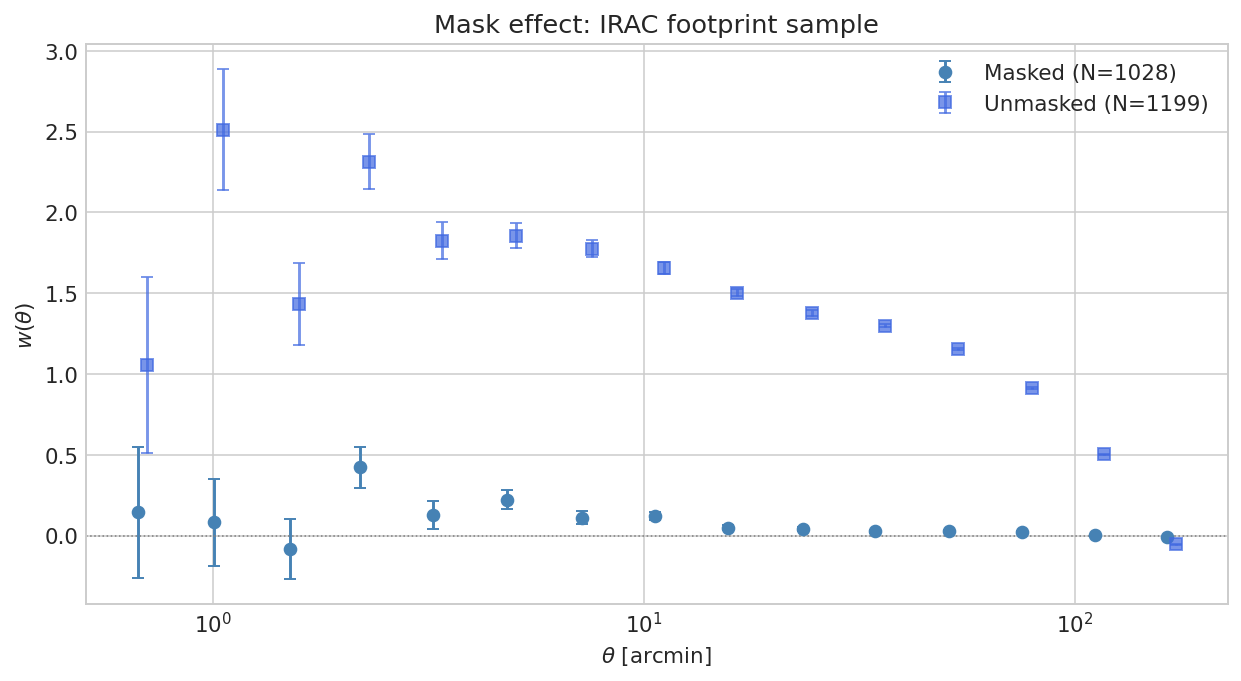

In [5]:
# Compare masked vs unmasked for the footprint sample
masked_path   = corr_dir / "2pacf_edf_s_irac_footprint.npz"
unmasked_path = corr_dir / "2pacf_edf_s_irac_footprint_unmasked.npz"

if masked_path.exists() and unmasked_path.exists():
    r_masked   = CorrelationResult.load(str(masked_path))
    r_unmasked = CorrelationResult.load(str(unmasked_path))

    fig, ax = plt.subplots(figsize=(9, 5))
    theta   = r_masked.theta_arcmin

    ax.errorbar(theta, r_masked.w,   yerr=compute_poisson_errors(r_masked),
                fmt="o", capsize=3, label=f"Masked (N={r_masked.n_galaxies})",
                color="steelblue")
    ax.errorbar(theta * 1.05, r_unmasked.w, yerr=compute_poisson_errors(r_unmasked),
                fmt="s", capsize=3, label=f"Unmasked (N={r_unmasked.n_galaxies})",
                color="royalblue", alpha=0.7)

    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\theta$ [arcmin]")
    ax.set_ylabel(r"$w(\theta)$")
    ax.set_title("Mask effect: IRAC footprint sample")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("(Need both masked and unmasked footprint results)")

## 5. Simulation error band on the primary sample

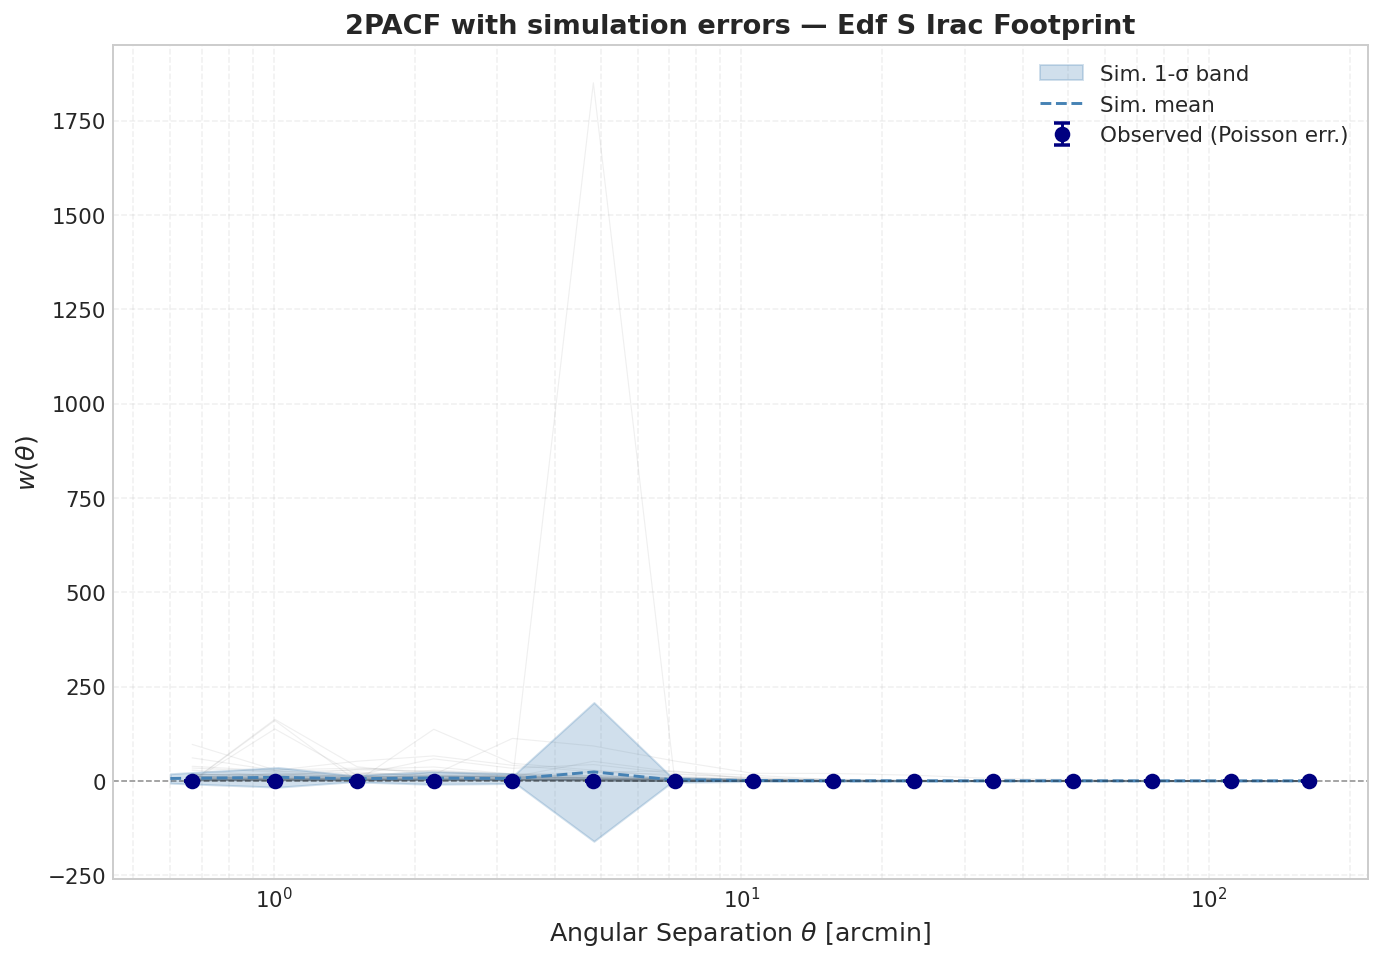

In [6]:
from src.plotting import plot_2pacf_with_sim_errors

primary    = "edf_s_irac_footprint"
corr_path  = corr_dir / f"2pacf_{primary}.npz"
sim_name   = cfg["simulations"]["active"]
sim_path   = resolve_path(cfg["paths"]["cov_dir"]) / f"sim_errors_{primary}_{sim_name}.npz"

if corr_path.exists() and sim_path.exists():
    result     = CorrelationResult.load(str(corr_path))
    sim_data   = np.load(str(sim_path))
    sim_errors = {
        "theta_deg"   : sim_data["theta_deg"],
        "theta_arcmin": sim_data["theta_arcmin"],
        "mean_w"      : sim_data["mean_w"],
        "std_w"       : sim_data["std_w"],
        "median_w"    : sim_data["median_w"],
        "all_w"       : sim_data["all_w"],
        "n_valid"     : sim_data["n_valid"],
    }
    fig, ax = plot_2pacf_with_sim_errors(
        result, sim_errors,
        title=f"2PACF with simulation errors — {primary.replace('_', ' ').title()}",
    )
    plt.show()
elif not corr_path.exists():
    print(f"2PACF result not found: {corr_path}")
else:
    print(f"Simulation errors not found: {sim_path}")
    print("Run: python scripts/run_simulations.py --sample edf_s_irac_footprint ...")

## 6. Science interpretation

### Clustering amplitude

The angular correlation length $\theta_0$ and power-law slope $\gamma$ constrain the
3D clustering via the Limber (1953) equation:

$$w(\theta) = \int_0^\infty n^2(z)\, \xi(r, z)\, dz \bigg/ \left[\int_0^\infty n(z)\, dz\right]^2$$

For a power-law $\xi(r) = (r/r_0)^{-\gamma}$, the projected form gives
$A \propto r_0^\gamma$.

### Galaxy bias

The linear bias $b$ is related to the correlation amplitude via
$\xi_{\rm LRD}(r) = b^2 \xi_{\rm DM}(r)$. Our constant bias model (set in
`config/analysis.yml`: `bias.value = 3.0`) is appropriate for the
massive host halos expected to harbour LRDs at $z \sim 5$–7.

### Sample comparison

- **Masked vs unmasked**: the mask removes galaxies near survey edges, reducing
  large-scale systematic effects. A significant change in $w(\theta)$ would indicate
  edge contamination.
- **IRAC detected**: the tiny sample precludes a robust measurement but provides
  an independent (if noisy) upper limit on LRD clustering.
- **No IRAC footprint**: this complementary sample allows a consistency check —
  if LRDs cluster equally regardless of IRAC coverage, the signal is robust.

## Summary table

In [7]:
print("\n" + "="*70)
print(" LRD 2PACF Analysis — Final Summary")
print("="*70)
print(f" Survey    : Euclid Deep Field South")
print(f" RA        : {cfg['fields']['edf_s']['ra_min']}° – {cfg['fields']['edf_s']['ra_max']}°")
print(f" Dec       : {cfg['fields']['edf_s']['dec_min']}° – {cfg['fields']['edf_s']['dec_max']}°")
print(f" Estimator : Landy-Szalay (1993)")
print(f" Bins      : {cfg['bins']['nbins']} log-spaced, "
      f"{cfg['bins']['min_sep']}° – {cfg['bins']['max_sep']}°")
print(f" Random N  : {cfg['randoms']['n_randoms_factor']}× N_gal")
print(f" Bias (b)  : {cfg['bias']['value']} (constant)")
print()
print(" Results available:")
for result, label, _ in loaded:
    print(f"   {label:35s} — {result.n_galaxies} galaxies, "
          f"{result.valid.sum()} positive bins")
print("="*70)


 LRD 2PACF Analysis — Final Summary
 Survey    : Euclid Deep Field South
 RA        : 55.0° – 67.5°
 Dec       : -52.5° – -44.5°
 Estimator : Landy-Szalay (1993)
 Bins      : 15 log-spaced, 0.009° – 3.3°
 Random N  : 100× N_gal
 Bias (b)  : 3.0 (constant)

 Results available:
   IRAC footprint (masked)             — 1028 galaxies, 15 positive bins
   IRAC footprint (unmasked)           — 1199 galaxies, 15 positive bins
   IRAC detected (masked)              — 16 galaxies, 6 positive bins
